# Deep learning project: image captioning

In this project we will train a transformer architecture to generate captions for images. We will train (and test) the model on the Flickr8k dataset, a dataset of 8000 image-captions pairs.

## Preprocessing

In this section we will prepare the datasets for the training and testing phases. Note that we will work from the folder of resized images, i.e. the images from the Flickr8k dataset which we have previously already resized to 224 x 224.

In [1]:
#We first copy the resized images folder from the mounted drive to the local Colab storage,
# as I/O is much faster from this local storage than from a mounted drive (according to the internet).
# Copying resized images from Google Drive to Colab local storage (should take around 5 mins)
from google.colab import drive
import os
drive.mount('/content/drive')
!rm -rf /content/images  # optional: remove old copy if it exists
!mkdir -p /content/images
!cp -r "/content/drive/MyDrive/Image_Captioning_Project_Final/Resized_Images"/* /content/images/

Mounted at /content/drive


As a first step, we will get all the image data into a training, validation and test image set based on the split encoded in the json file. Because one single image has 5 captions, each image provides 5 image-caption samples. These captions will be stored in the training, validation and test target set. The training, validation and test datasets will then for each caption contain the indices of the corresponding image in the training, validation or test image set.

This will form the basis of our custom dataset.

In [18]:
from PIL import Image
import os
import numpy as np
import json
import torch

with open('flickr8k_simplified.json', 'r') as file:
    split_file = json.load(file)

src_dir = '/content/images'

# Data validation: Track missing files and empty captions
missing_files = []
empty_captions = []

training_images=[] #Will contain the actual images
training_target=[] #Will contain the (untokenized) captions (so 5 per image)
training_data=[]   #Will be of the same length as the target set, and will for each corresponding caption contain the index in training_images
validation_images=[] #Same logic for validation and test sets
validation_target=[]
validation_data=[]
test_images=[]
test_target=[]
test_data=[]

training_index=0
validation_index=0
test_index=0

for json_object in split_file:
  filename = json_object['filename']
  src_path = os.path.join(src_dir, filename)
  split = json_object['split']

  #Check if file exists
  if not os.path.exists(src_path):
    missing_files.append(filename)
    print(f'file is {filename}')
    continue

  #Check for empty captions
  if not json_object['sentences'] or len(json_object['sentences']) == 0:
    empty_captions.append(filename)
    print(f'captions missing for {filename}')
    continue

  try:
    image = Image.open(src_path).convert("RGB")
    #Check image size
    if image.size != (224, 224):
      print(f'file {filename} is not 224x224 -> {image.size}')
  except Exception as e:
    print(f'Error loading image {filename}: {e}')
    continue

  if split=='train':
    training_images.append(image)
    training_target.extend(json_object['sentences'])
    training_data.extend([training_index]*len(json_object['sentences']))
    training_index=training_index+1

  elif split=='val':
    validation_images.append(image)
    validation_target.extend(json_object['sentences'])
    validation_data.extend([validation_index]*len(json_object['sentences']))
    validation_index=validation_index+1

  elif split=='test':
    test_images.append(image)
    test_target.extend(json_object['sentences'])
    test_data.extend([test_index]*len(json_object['sentences']))
    test_index=test_index+1

  else:
    print('Weird split value: ' + str(split) + ' for filename ' + str(filename))

print(f'\n**********Data Loading Summary***********')
print(f'total training images: {len(training_images)} - total training captions: {len(training_target)}')
print(f'total validation images: {len(validation_images)} - total validation captions: {len(validation_target)}')
print(f'total test images: {len(test_images)} - total test captions: {len(test_target)}')
if missing_files:
  print(f'total missing files: {len(missing_files)}')
if empty_captions:
  print(f'total empty captions: {len(empty_captions)}')




**********Data Loading Summary***********
total training images: 6000 - total training captions: 30000
total validation images: 1000 - total validation captions: 5000
total test images: 1000 - total test captions: 5000


Now we'll define the transforms we will perform on each sample (i.e. the image). For the training set, we will do some data augmentation (to avoid overfitting) as well as the ToTensor transform (which transforms the image to a tensor with values in [0,1] and with shape C x H x W). We will also normalize the images according to the standard ImageNet normalization. For the validation and test set, we solely perform the ToTensor transform and normalization. The data augmentation we perform on the training set is rather minimal, since we don't want to 'shake up' images too much so that they don't lose their semantical correspondence to the caption.

In [19]:
import torchvision
import torchvision.transforms as transforms

# Image normalization: Standard ImageNet normalization statistics
# This helps neural networks train better by centering pixel values around 0
# Mean and std values are from ImageNet dataset
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(0.2),
    transforms.ToTensor(),
    normalize
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    normalize
])

Now we have more or less dealt with the preprocessing on the images side. Now we should also preprocess the captions, more specifically tokenize them. We will first explore the captions a little more to get an idea of how to meaningfully tokenize them.

In [20]:
#Let's just print the first 20 captions to get an idea of what a typical caption looks like.
for caption in training_target[:20]:
    print(caption)

a black dog is running after a white dog in the snow .
black dog chasing brown dog through snow
two dogs chase each other across the snowy ground .
two dogs play together in the snow .
two dogs running through a low lying body of water .
a little baby plays croquet .
a little girl plays croquet next to a truck .
the child is playing croquette by the truck .
the kid is in front of a car with a put and a ball .
the little boy is playing with a croquet hammer and ball beside the car .
a brown dog in the snow has something hot pink in its mouth .
a brown dog in the snow holding a pink hat .
a brown dog is holding a pink shirt in the snow .
a dog is carrying something pink in its mouth while walking through the snow .
a dog with something pink in its mouth is looking forward .
a brown dog is running along a beach .
a brown dog wearing a black collar running across the beach .
a dog walks on the sand near the water .
brown dog running on the beach .
the large brown dog is running on the beac

A first thing we notice is that most sentences end with a period. Since a caption can always be ended with a period, it doesn't really add any semantics, so we opt for omitting all periods at the end of the caption (an end of sentence token provides the same semantics anyway).

In [21]:
def clean_caption(caption):
    """This omits the period at the end of the caption as well as possible trailing spaces."""
    return caption.rstrip().rstrip('.').rstrip()

training_target = [clean_caption(caption) for caption in training_target]
validation_target = [clean_caption(caption) for caption in validation_target]
test_target = [clean_caption(caption) for caption in test_target]

print(f"Cleaned {len(training_target)} training captions")
print(f"Cleaned {len(validation_target)} validation captions")
print(f"Cleaned {len(test_target)} test captions")

Cleaned 30000 training captions
Cleaned 5000 validation captions
Cleaned 5000 test captions


Now, our intuition tells us that because of the limited size of the Flickr8k dataset, there will be a lot of words which only appear once or twice in the whole dataset. If we were to create our own custom word-level vocabulary, this would lead to a lot of 'unk' tokens which doesn't really help our model. The Internet now tells us that as a solution for that a subword tokenizer can be used. Such a tokenizer learns how to tokenize sentences into a sequence of subwords, for example tokenizing the word 'running' as 'run' and the suffix 'ing'. We can use such a trained subword tokenizer to tokenize our training and testing caption sets.

In [22]:
#We'll train the sentencepiece subword tokenizer on our list of captions from the training set (first temporarily writing them to a file since sentencepiece expects this as training format)
import sentencepiece as spm
import tempfile

#We'll also print some stats of the captions to get a 'feel' for the data.
print("*******caption stats*******")
caption_lengths = [len(caption.split()) for caption in training_target]
print(f"average caption length: {np.mean(caption_lengths):.2f} words")
print(f"min caption length: {min(caption_lengths)} words")
print(f"max caption length: {max(caption_lengths)} words")
print(f"median caption length: {np.median(caption_lengths):.2f} words")

#We write to a temporary file for training
with tempfile.NamedTemporaryFile(mode='w', delete=False) as f:
    for caption in training_target:
        f.write(caption.lower() + '\n')
    temp_path = f.name

spm.SentencePieceTrainer.train(input=temp_path, model_prefix='spm_model', vocab_size=2000, pad_id=0, unk_id=1, bos_id=2, eos_id=3)  #SentencePiece does not by default include a pad token, but we will need it for batching, so we enable it.

*******caption stats*******
average caption length: 10.88 words
min caption length: 2 words
max caption length: 37 words
median caption length: 10.00 words


We'll now look at a few examples of the SentencePiece tokenizer's functionalities.

In [23]:
sp = spm.SentencePieceProcessor(model_file='spm_model.model')
sp.encode(["a dog playing in the snow", "a boat on the sea"])  #An example of what the tokenizer does

[[4, 11, 43, 5, 6, 41], [4, 216, 8, 6, 815]]

In [24]:
sp.decode([[4, 11, 43, 5, 6, 41], [4, 216, 8, 6, 815]]) #decoding back into text

['a dog playing in the snow', 'a boat on the sea']

We can also look at the ids for the special tokens (< pad >, < unk >, < bos >, < eos >).

In [25]:
print(sp.pad_id())
print(sp.unk_id())
print(sp.bos_id())
print(sp.eos_id())

0
1
2
3


By default sp.encode() does not include the < bos > and < eos > tokens, but in our transformer architecture we will need them, so we should enable this in sp.encode().

In [26]:
sp.encode(["a dog playing in the snow", "a boat on the sea"], add_bos= True, add_eos= True)  #An example of what the tokenizer does

[[2, 4, 11, 43, 5, 6, 41, 3], [2, 4, 216, 8, 6, 815, 3]]

In [27]:
sp.decode([[2, 4, 11, 43, 5, 6, 41, 3], [2, 4, 216, 8, 6, 815, 3]]) #decoding back into text

['a dog playing in the snow', 'a boat on the sea']

Now we'll tokenize our caption sets, as well as pad them so the dataloader can make uniform-sized tensor batches later on.

In [28]:
#We tokenize the captions (after making them lower-case as we did in the SentencePiece training as well)
train_tokens = [sp.encode(caption.lower(), add_bos=True, add_eos=True) for caption in training_target]
val_tokens   = [sp.encode(caption.lower(), add_bos=True, add_eos=True) for caption in validation_target]
test_tokens  = [sp.encode(caption.lower(), add_bos=True, add_eos=True) for caption in test_target]

#Padding to max length
def pad_sequences(seqs, pad_id=sp.pad_id()):
    max_len = max(len(s) for s in seqs)
    return torch.tensor([s + [pad_id] * (max_len - len(s)) for s in seqs])

train_tokens = pad_sequences(train_tokens)
val_tokens   = pad_sequences(val_tokens)
test_tokens  = pad_sequences(test_tokens)

# Print tokenization statistics
print(f"\n*******Tokenization stats*******")
print(f"training: {len(train_tokens)} sequences, max length: {train_tokens.shape[1]}")
print(f"validation: {len(val_tokens)} sequences, max length: {val_tokens.shape[1]}")
print(f"test: {len(test_tokens)} sequences, max length: {test_tokens.shape[1]}")



*******Tokenization stats*******
training: 30000 sequences, max length: 54
validation: 5000 sequences, max length: 42
test: 5000 sequences, max length: 47


Now we'll define our custom dataset class and initialize our training, validation and test sets.

We'll also already initialize the train, validation and test dataloaders.

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader


class CustomDataset(Dataset):

    def __init__(self, x, y,  image_set, transform=None):
        self.x = x  #In our case this will be the list of indices to the corresponding image for each caption in y.
        self.y = y  #The list of captions.
        self.image_set = image_set #The corresponding set of images.
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        sample = self.image_set[self.x[idx]]
        target = self.y[idx]
        if self.transform:
          sample = self.transform(sample)
        return sample, target


training_set = CustomDataset(training_data, train_tokens, training_images, transform_train)
validation_set = CustomDataset(validation_data, val_tokens, validation_images, transform_test)
test_set = CustomDataset(test_data, test_tokens, test_images, transform_test)


In [30]:
train_dataloader = DataLoader(training_set, batch_size=128, shuffle=True)
validation_dataloader = DataLoader(validation_set, batch_size=128, shuffle=False)
test_dataloader = DataLoader(test_set, batch_size=128, shuffle=False)

We'll do a quick check to confirm that everything concerning preprocessing has gone the way we would expect it to work.

In [31]:
#Let's see if everything has gone the way we would like it to, up until now.
images, tokenized_captions = next(iter(train_dataloader))
print(images.shape)
print(tokenized_captions.shape)
print(tokenized_captions[0])
sp.decode(tokenized_captions[0].tolist())

torch.Size([128, 3, 224, 224])
torch.Size([128, 54])
tensor([  2,   4,  19,  26, 690,  84,  79,   4,  37, 156, 113,   3,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0])


'a boy wearing goggles jumps into a blue swimming pool'

Everything concords with what we would expect, which means we can start thinking about the architecture now.

##Architecture

### Patching and position encoding

As a first step we need a module which takes the image as input, and produces a tensor of flattened patches. We will call this the patcher. The patcher will take the image, divide it into patches, flatten the patches and project the patches to an embedding, which should be of the embedding size our transformer expects.

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Patcher(nn.Module):

    def __init__(self, patch_size, embedding_size, nr_channels=3): #We'll assume square patches of shape patch_size x patch_size  #channels is usually 3 (RGB)

        super(Patcher, self).__init__()
        self.patch_size = patch_size
        self.embedding_size = embedding_size
        self.nr_channels = nr_channels

        self.W_e = nn.Linear(patch_size*patch_size*nr_channels, embedding_size)

    def forward(self, x):  #the patcher receives a batch of images as input
        # x: batch_size x channels x height x width
        # N = number of patches = height/patch_size * width/patch_size

        patches = F.unfold(x, kernel_size=self.patch_size, stride=self.patch_size) #slides over the images, returns batch size x channels*patch_size*patch_size x N
        patches = patches.transpose(1, 2).flatten(start_dim=2)
        patch_embeddings = self.W_e(patches)

        return patch_embeddings

Let's quickly test our patcher with patch size 16 x 16 and embedding size 512 on a random batch of our training images and see if the shape of the output corresponds to what we would expect.

In [33]:
test_patcher = Patcher(16, 512)
images, tokenized_captions = next(iter(train_dataloader))
patch_embeddings = test_patcher(images)
patch_embeddings.shape

torch.Size([128, 196, 512])

We see that we get a shape of 128 x 196 x 512. So we see that for all 128 instances in the batch, we get 196 patch embeddings. 196 patches corresponds to what we would expect since our images are 224 x 224 -> N = H/P * W/P = (224/16) * (224/16) = 14 * 14 = 196. Furthermore, we see that each patch embedding is of the size 512, which is the embedding size we specified. So everything concords with what we expected. We can now move on to the position encoding.

As a next step, we need a module which encodes positional information into the patches. Later on, we will also need this position encoder to encode positional information into the tokens of our text sequences. Hence, we will construct this class with both purposes in mind (since both purposes are essentially the same).

In [34]:
import math

class PositionEncoder(nn.Module):

    def __init__(self, max_seq_length, embedding_dim):
        # For images, the maximum sequence length is the number of patches of a single image.
        # For text sequences, the maximum sequence length is the maximum length of a text sequence.
        # Having the maximum sequence length and embedding dimension passed, allows us to precompute
        # the positional encodings once and then reuse them across all batches.

        super(PositionEncoder, self).__init__()

        pos_encodings = torch.tensor([[math.sin(pos/pow(10000, (2*(i//2)/embedding_dim))) if i%2==0 else math.cos(pos/pow(10000, (2*(i//2)/embedding_dim))) for i in range(embedding_dim) ] for pos in range(max_seq_length)])

        self.register_buffer("pos_encodings", pos_encodings) #This ensures that when we save the model at some point, the pos_encodings are included in the checkpoint.

    def forward(self, x):  #The patcher receives a batch of patch/token embeddings and returns these embeddings but with the position encodings added to them.
        seq_len = x.shape[1]
        return x + self.pos_encodings[:seq_len, :].to(x.device) #This ensures compatibility between the device of the batch and the pos_encodings

Let's test it on the patch embeddings we got from our patching module test.

In [35]:
test_pos_encoder = PositionEncoder(patch_embeddings.shape[1], patch_embeddings.shape[2])
pos_encoded_embeddings = test_pos_encoder(patch_embeddings)
pos_encoded_embeddings.shape

torch.Size([128, 196, 512])

Everything works the way we would expect it to. We can now move on to the actual Transformer architecture, starting with the encoder.

### Encoder

The Transformer architecture will be mostly based on the descriptions in the seminal paper 'Attention is all you need' (Vaswani et al.) . However, since our dataset is very small, we plan to downsize the model compared to the one described in the paper. For example, the encoder in the paper is composed of a stack of 6 layers (each containing a self-attention module and a feed-forward network). The decoder in the paper is also composed of a stack of 6 decoder layers. We will use less layers to avoid overfitting on our small dataset. We will try to to keep our code as modular as possbile so it is easy to experiment with different configurations.

First part of the encoder module is the self-attention module. As mentioned above, the implementation is based on the descriptions found in the seminal paper of Vaswani et al.

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):

    def __init__(self, embedding_size, key_size): # We will assume the key, value and query dimensions to be equal (embedding_size/nr_of_heads)
        super(SelfAttention, self).__init__()
        self.embedding_size = embedding_size
        self.key_size = key_size

        self.W_Q = nn.Linear(embedding_size, key_size) #Weights to get the queries
        self.W_V = nn.Linear(embedding_size, key_size) #Weights to get the values
        self.W_K = nn.Linear(embedding_size, key_size) #Weights to get the keys

    def forward(self, x):
        #The self-attention module gets a batch, in each sample of the batch a sequence of patches.
        #The self-attention module then computes keys, values and queries for each patch.
        #The self-attention module then for each patch computes the similarities, i.e. the scaled dot-product of the query of the patch with the keys of the other patches.
        #It passes softmax over these similarity scores, and the results of this softmax are the weights in the weighted sum of the values of all patches to get the self-attention value for that patch.

        queries = self.W_Q(x) # batch_size x nr_of_patches x query_size
        values = self.W_V(x) # batch_size x nr_of_patches x value_size
        keys = self.W_K(x)   # batch_size x nr_of_patches x key_size

        similarities = torch.bmm(queries, keys.permute(0,2,1))/math.sqrt(self.key_size)  #batch_size x nr_of_patches x nr_of_patches

        similarities = F.dropout(similarities, p=0.2, training=self.training)  # A measure to reduce overfitting

        similarities = F.softmax(similarities, dim=-1) #Softmax over the scaled dot products per patch (computed to the other patches)

        attention_values = torch.bmm(similarities, values)

        return attention_values  #shape: batch_size x nr_of_patches x key_size (=value_size)

Let's see if what it gives, makes sense if we pass our previously position encoded patch embeddings into it.

In [37]:
test_self_attention = SelfAttention(patch_embeddings.shape[2], patch_embeddings.shape[2])
attention_values = test_self_attention(patch_embeddings)
attention_values.shape

torch.Size([128, 196, 512])

It appears to be working the way it should. From this, making a multi-head self-attention module is extremely simple.

We will approach the multi-head self-attention module by implementing what it conceptually is, i.e. a set of parallel attention layers. We are aware that implementing a multi-head self-attention module can be implemented in a more efficient way by implementing it as one single matrix multiplication (which can happen parallelized under the hood) and then using .view() or .reshape() to split the result into heads.

However, since our main objective for this project is to gain clear conceptual understanding of the architecture we build, we have opted to retain our more conceptual implementation of the multi-head self-attention module. Furthermore, during training we noticed that training went quite fast and that overfitting happens quickly. As a result of this, we implement early stopping and only have to train for a limited number of epochs. Hence, the speed-up we could achieve by adjusting our multi-head self-attention implementation is not very relevant (the same goes for multi-head cross-attention implemented later on in the decoder).

In [38]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(self, embedding_size, nr_heads):  #Embedding size should be divisable by the number of heads.
        assert((embedding_size%nr_heads)==0)
        super(MultiHeadSelfAttention, self).__init__()
        self.embedding_size = embedding_size
        self.nr_heads = nr_heads

        self.multiheads = nn.ModuleList()
        for i in range(nr_heads):
          self.multiheads.append(SelfAttention(embedding_size, embedding_size//nr_heads))

        self.W_O = nn.Linear(embedding_size, embedding_size) #After concatenating the attention results of the different heads, we linearly project.

    def forward(self, x):

        multi_head_attentions = []
        for i in range(self.nr_heads):
          multi_head_attentions.append(self.multiheads[i](x))

        multi_head_attentions = torch.cat(multi_head_attentions, dim = 2)   # concatenate the multi-head attention results.

        multi_head_attentions = F.dropout(multi_head_attentions, p=0.2, training=self.training)  # A measure to reduce overfitting

        attention_values = self.W_O(multi_head_attentions)

        return attention_values

A quick test to see if the shape of the output concords to what we expect.

In [39]:
test_multi_head_self_attention = MultiHeadSelfAttention(patch_embeddings.shape[2], 4)
attention_values = test_multi_head_self_attention(patch_embeddings)
attention_values.shape

torch.Size([128, 196, 512])

Each (multihead) self-attention module is followed by a feed-forward network. We will implement the feed-forward network in the style of the 'Attention is all you need' paper, i.e. two linear transformations with a ReLu activation layer in between.

In [40]:
class FFNetwork(nn.Module):

    def __init__(self, embedding_size, hidden_size):
        super(FFNetwork, self).__init__()
        self.embedding_size = embedding_size
        self.hidden_size = hidden_size
        self.first_layer = nn.Linear(embedding_size, hidden_size)
        self.second_layer = nn.Linear(hidden_size, embedding_size)

    def forward(self, x):

        x = self.first_layer(x)
        x = torch.relu(x)
        x = F.dropout(x, p=0.25, training=self.training)  # A measure to reduce overfitting
        x = self.second_layer(x)

        return x

Now by simply combining all of these modules, we can form the encoder. In the syle of Vaswani et al. (2017), each encoder layer consists of two sub-layers, namely a multi-head self-attention module and a feed-forward network. Each sub-layer is followed by a residual connection and a layer normalization.

In [41]:
class Encoder(nn.Module):

    def __init__(self, embedding_size, nr_layers, nr_heads, ffn_hidden_size):
        super(Encoder, self).__init__()
        self.nr_layers = nr_layers
        self.encoder_stack = nn.ModuleList()

        for i in range(nr_layers):
          self.encoder_stack.extend([MultiHeadSelfAttention(embedding_size, nr_heads),
                                     nn.LayerNorm(embedding_size),
                                     FFNetwork(embedding_size, ffn_hidden_size),
                                     nn.LayerNorm(embedding_size)])

    def forward(self, x):

        encoder_output = x
        for i in range(self.nr_layers):
          encoder_output = encoder_output + self.encoder_stack[4*i](encoder_output)  #apply the MH self-attention as residual connection
          encoder_output = self.encoder_stack[4*i+1](encoder_output) #apply LayerNorm
          encoder_output = encoder_output + self.encoder_stack[4*i+2](encoder_output) #apply the FF network
          encoder_output = self.encoder_stack[4*i+3](encoder_output) #apply LayerNorm

        return encoder_output



Now, before moving on to the Decoder, we'll test the whole pipeline up until now and see if the shape of the output concords with what we expect.

In [42]:
patch_size = 16
embedding_size = 512
image_h = 224
image_w = 224
nr_of_patches = (image_h // patch_size) * (image_w // patch_size)
images, tokenized_captions = next(iter(train_dataloader))

patcher0 = Patcher(patch_size, embedding_size)
pos_encoder0 = PositionEncoder(nr_of_patches, embedding_size)
encoder0 = Encoder(embedding_size, 2, 4, 1024)
encoder_outputs = encoder0(pos_encoder0(patcher0(images)))
encoder_outputs.shape

torch.Size([128, 196, 512])

### Decoder

#### Cross-Attention Mechanism

Cross-Attention is where the actual "image captioning" magic happens. Up until now, the encoder just looked at the image. And the self-attention mechanism of the decoder just looks at the text.

in **Cross-Attention**, the two finally meet.
* **Queries** come from the **Decoder** (the sentence we are trying to build).
* **Keys and Values** come from the **Encoder** (the image features).

Essentially, for every word the model generates, it "looks" back at the image to see which patch is most relevant. This is the standard encoder-decoder attention described in *Vaswani et al. (attention is all you need)*.

In [43]:
class CrossAttention(nn.Module):

    def __init__(self, embedding_size, key_size):
        super(CrossAttention, self).__init__()

        #only need key_size in forward pass
        self.key_size = key_size
        #queries come from the text(decoder input)
        self.W_Q = nn.Linear(embedding_size, key_size)

        # keys and values come from the image(encoder output)
        # this is what lets the text attend to specific image patches
        self.W_V = nn.Linear(embedding_size, key_size)
        self.W_K = nn.Linear(embedding_size, key_size)

    def forward(self, x, encoder_output):
        # x is the text input (batch_size x seq_len x embed_dim)
        # encoder_output is the output of the encoder on the image patches (batch_size x nr_of_patches x embed_dim)


        #text asks for information
        queries = self.W_Q(x)
        #image offers content
        values = self.W_V(encoder_output)
        #keys to match the query
        keys = self.W_K(encoder_output)
        #standard scaled dot-product attention
        #transpose the keys to align dimensions for matrix multiplication
        similarities = torch.bmm(queries, keys.transpose(1,2))/math.sqrt(self.key_size)
        similarities = F.dropout(similarities, p=0.2, training=self.training)  # Dropout as a measure to reduce overfitting
        similarities = F.softmax(similarities, dim=-1)  # softmax for probability distribution over images

        #compute weighted sum of values( batch matrix x matrix)
        attention_values = torch.bmm(similarities, values)

        return attention_values

In [44]:
class MultiHeadCrossAttention(nn.Module):

    def __init__(self, embedding_size, nr_heads):
      # sanity check: embedding size must split evenly across heads
        super(MultiHeadCrossAttention, self).__init__()
        assert((embedding_size%nr_heads)==0)

        self.nr_heads = nr_heads
        self.multiheads = nn.ModuleList()
        # create heads of CrossAttention
        for i in range(nr_heads):
          self.multiheads.append(CrossAttention(embedding_size, embedding_size//nr_heads))
        #linear projection to mix results from all heads
        self.W_O = nn.Linear(embedding_size, embedding_size) #After concatenating the attention values of the different heads, we linearly project

    def forward(self, x, encoder_output):
        #collect output from all heads
        multi_head_attentions = []
        for i in range(self.nr_heads):
          multi_head_attentions.append(self.multiheads[i](x, encoder_output))

        multi_head_attentions = torch.cat(multi_head_attentions, dim = 2)   # concatenate the multi-head attentions
        multi_head_attentions = F.dropout(multi_head_attentions, p=0.2, training=self.training)  # Dropout as a measure to reduce overfitting
        return self.W_O(multi_head_attentions)

### Masked Self-Attention (Causal Masking)

Since we are generating text, we have to be careful not to "cheat". When the model tries to predict the word "dog" in the sentence "a big dog", it shouldn't be allowed to see the word "dog" yet.

To fix this, we use a **Causal Mask** (also called a look-ahead mask). It forces the attention scores for future positions to be `-inf`, effectively zeroing them out after softmax.

In [45]:
class MaskedSelfAttention(nn.Module):
    def __init__(self, embedding_size, key_size):
        super(MaskedSelfAttention, self).__init__()
        self.key_size = key_size

        self.W_Q = nn.Linear(embedding_size, key_size)
        self.W_K = nn.Linear(embedding_size, key_size)
        self.W_V = nn.Linear(embedding_size, key_size)

    def forward(self, x, mask=None):
        queries = self.W_Q(x)
        keys = self.W_K(x)
        values = self.W_V(x)
        #compute similarities
        similarities = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(self.key_size)
        similarities = F.dropout(similarities, p=0.15, training=self.training)  # Dropout as a measure to reduce overfitting
        #Mask:
        # whereever the mask is 0(future), set score to -inf
        if mask is not None:
            # Masking future tokens with -inf
            similarities = similarities.masked_fill(mask == 0, float('-inf'))

        weights = F.softmax(similarities, dim=-1)
        return torch.bmm(weights, values)

class MultiHeadMaskedSelfAttention(nn.Module):
    def __init__(self, embedding_size, nr_heads):
        super(MultiHeadMaskedSelfAttention, self).__init__()
        self.nr_heads = nr_heads
        #list of masked heads
        self.multiheads = nn.ModuleList([MaskedSelfAttention(embedding_size, embedding_size//nr_heads) for _ in range(nr_heads)])
        self.W_O = nn.Linear(embedding_size, embedding_size)

    def forward(self, x, mask):
        #run each head and concatenate
        heads = [self.multiheads[i](x, mask) for i in range(self.nr_heads)]
        head_outputs = torch.cat(heads, dim=2)
        head_outputs = F.dropout(head_outputs, p=0.2, training=self.training)  # Dropout as a measure to reduce overfitting
        return self.W_O(head_outputs)

### Decoder Layer Structure

Following the architecture from the paper, each decoder layer has 3 sub-blocks. Each sub-block is followed by a residual connection and layer normalization to help with training stability (gradients flow better).

1.  **Masked Self-Attention**: look at previous words.
2.  **Cross-Attention**: look at the image patches.
3.  **Feed-Forward**: process the features.

In [46]:
class DecoderLayer(nn.Module):
    def __init__(self, embedding_size, nr_heads, ffn_hidden_size):
        super(DecoderLayer, self).__init__()

        # self attention(masked)
        self.masked_sa = MultiHeadMaskedSelfAttention(embedding_size, nr_heads)
        self.norm1 = nn.LayerNorm(embedding_size)
        #cross-attention
        self.cross_attn = MultiHeadCrossAttention(embedding_size, nr_heads)
        self.norm2 = nn.LayerNorm(embedding_size)

        # feed forward
        #reusing FFnetwork from earlier
        self.ffn = FFNetwork(embedding_size, ffn_hidden_size)
        self.norm3 = nn.LayerNorm(embedding_size)

    def forward(self, x, encoder_output, mask):
        # masked self-attention
        # sub-layer 1: masked self-attention + residual + norm
        # we add x (residual) to help gradients flow through deep networks
        attn_out = self.masked_sa(x, mask)
        x = self.norm1(x + attn_out)
        # sub-layer 2: cross-attention + residual + norm
        # encoder_output serves as key/value here
        cross_out = self.cross_attn(x, encoder_output)
        x = self.norm2(x + cross_out)
        # sub-layer 3: feed-forward + residual + norm
        ffn_out = self.ffn(x)
        x = self.norm3(x + ffn_out)
        return x

Now that we have constructed the DecoderLayer class, we can use it to build the full Decoder architecture. As input the Decoder takes tokenized captions and the encoder outputs. The Decoder returns sequences of logits. These sequences of logits can then, during training or inferring, be passed through softmax to convert them to sequences of tokens. Such a sequence of tokens can then be used to calculate the loss compared to the target sequence, or can be decoded to actually generate the predicted text caption we are interested in.

Since we also want to encode positional info into the tokenized captions, we reuse the earlier PositionEncoder class within the Decoder.


In [47]:
class Decoder(nn.Module):
    def __init__(self, embedding_size, nr_layers, nr_heads, ffn_hidden_size, vocab_size, max_seq_len=100):
        super(Decoder, self).__init__()
        # Token id-> vectors (embeddings)
        self.embedding = nn.Embedding(vocab_size, embedding_size, padding_idx=0)
        # Using the PositionEncoder class we defined at the start to add positional info to the caption embeddings
        self.pos_encoder = PositionEncoder(max_seq_len, embedding_size)
        # Stack of decoder layers
        self.layers = nn.ModuleList([DecoderLayer(embedding_size, nr_heads, ffn_hidden_size) for _ in range(nr_layers)])
        # Final linear layer to map to vocab
        self.fc_out = nn.Linear(embedding_size, vocab_size)

    def forward(self, x, encoder_output):
        # We create the causal mask (lower triangular matrix of 1s)
        # This ensures position i can only see positions 0 to i
        seq_len = x.shape[1]
        mask = torch.tril(torch.ones((seq_len, seq_len), device=x.device, dtype=torch.bool)).unsqueeze(0)
        x = self.embedding(x) # From the pure sequence of tokens, we go to sequence of embeddings
        x = F.dropout(x, p=0.15, training=self.training) # Dropout as a measure against overfitting
        x = self.pos_encoder(x) #We add positional info to the sequence of embeddings

        #Finally we apply the stack of decoder blocks.
        for layer in self.layers:
            x = layer(x, encoder_output, mask)
        return self.fc_out(x)  #The stack of decoder blocks give as an output sequences of embeddings.
                               # As a last step, we linearly map the embeddings back to the vocab (which gives logits over the vocab).

### Full Transformer Architecture

Putting all of the previously described components together, we create the `ImageCaptioningTransformer` class which holds the Encoder (image) and Decoder (text).


In [48]:
class ImageCaptioningTransformer(nn.Module):
    def __init__(self, embedding_size, nr_enc_layers, nr_dec_layers, nr_heads, ffn_hidden_size, vocab_size, patch_size=16):
        super(ImageCaptioningTransformer, self).__init__()
        # --- Encoder pipeline ---
        # Turning image into patches + adding positional info
        # Then feeding the patch embeddings into to the encoder to give us the encoder outputs.
        self.patcher = Patcher(patch_size, embedding_size)
        self.pos_encoder_img = PositionEncoder((224//patch_size)**2, embedding_size)  #(224//patch_size)**2 equals the number of patches since our images are 224x224
        self.encoder = Encoder(embedding_size, nr_enc_layers, nr_heads, ffn_hidden_size)

        # --- Decoder ---
        self.decoder = Decoder(embedding_size, nr_dec_layers, nr_heads, ffn_hidden_size, vocab_size)

    def forward(self, images, captions):
        img_features = self.encoder(self.pos_encoder_img(self.patcher(images)))  # Encoder pipeline
        return self.decoder(captions, img_features)  # Decoder pipeline, which generates the actual text, i.e. the predicted captions

## Training

Now that the architecture is defined, we proceed to training the architecture. We will be using a standard training loop with the Adam optimizer and CrossEntropyLoss.

Before training, there are a number of hyperparameters we have to set, such as the learning rate but also architectural parameters, such as the number of heads and number of layers. As we mentioned before, our dataset is small and thus our model will be prone to overfitting. For this reason, we have chosen to keep the model architecture relatively simple.

We experimented with a few different configurations, ultimately choosing an architecture with embedding size 256 and consisting of two encoder layers and two decoder layers, both with four heads. We chose these hyperparameters based on the performance of the model on the validation set. If we had more time, we would have undertaken a more formal approach to hyperparameter tuning, with more extensive experiments.

For training the decoder, it is important to understand what we give it as input and with what we compare its outputs:

 **Teacher Forcing Inputs:** The input to the decoder is the caption *without* the last token.

 **Targets:** The target is the caption *shifted by one*, i.e., without the first token (`<bos>`).



In [51]:
# We check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Hyperparameters
BATCH_SIZE = 128
LEARNING_RATE = 1e-4 # Transformers usually like lower learning rates (3e-4 or 1e-4)
EPOCHS = 40

# Model dimensions (are also hyperparameters)
EMBEDDING_SIZE = 256
NR_HEADS = 4
NR_ENC_LAYERS = 2
NR_DEC_LAYERS = 2       # Not too much to prevent overfitting
FFN_HIDDEN = 512
VOCAB_SIZE = 2000   # match SentencePiece
PATCH_SIZE = 16

# Model
model = ImageCaptioningTransformer(
    patch_size=PATCH_SIZE,
    embedding_size=EMBEDDING_SIZE,
    nr_heads=NR_HEADS,
    nr_enc_layers=NR_ENC_LAYERS,
    nr_dec_layers=NR_DEC_LAYERS,
    ffn_hidden_size=FFN_HIDDEN,
    vocab_size=VOCAB_SIZE
).to(device)

# Optimization
# Ignore 0 in loss calculation so model doesnt get penalized for padding
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

#We introduce a LR scheduler which reduces the LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',           # Reduce when metric decreases (we want lower val loss)
    factor=0.5,           # Multiply LR by 0.5 when reducing (halve the learning rate)
    patience=3,           # Wait 3 epochs without improvement before reducing
)

def calculate_validation_loss(model, dataloader, criterion, device):
    """Calculate validation loss for monitoring overfitting and for choosing hyperparameters."""
    model.eval()  # Important: This turns off dropout
    total_val_loss = 0

    with torch.no_grad():  # No need to track gradients for validation
        for batch_idx, (images, captions) in enumerate(dataloader):
            images = images.to(device)
            captions = captions.to(device)

            # Prepare inputs just like in training
            decoder_input = captions[:, :-1]
            targets = captions[:, 1:]

            outputs = model(images, decoder_input)

            # Calculate loss
            loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(dataloader)
    return avg_val_loss

Training on device: cuda


Now that the hyperparameters are set, the model initialized and a function to calculate the validation loss defined, we can begin the actual training loop.

Once we started training our architecture, we immediately noticed that the model was prone to overfitting (even after simplifications such as reducing the number of layers and increasing dropout rates). The loss on the training set kept slowly going down, but after a while, the loss on the validation set stagnated and didn't go down any further. From that point on, the model is only overfitting: it learns to perform the task purely for the training data. This causes the model to lose the capacity to generalize on unseen data.

In order to prevent overfitting, we explictily save the model which performs best for the validation set, and we perform early stopping. In order to perform early stopping, we monitor the difference in performance on the training set and the validation set. If this gap in performance has been above a certain acceptable value for a number of epochs in a row (the 'patience' period), we stop training.

In [34]:
import time

print("Starting Training...")

# Track best validation loss for saving best model
best_val_loss = float('inf')

# Early stopping: stop if gap between train and val loss is too large
MAX_GAP = 0.5  # Stop if gap exceeds this value
gap_exceeded_epochs = 0  # Track consecutive epochs with large gap
patience = 2 # We will stop training if the gap is too large for two consecutive epochs

for epoch in range(EPOCHS):
    model.train()
    start_time = time.time()
    total_loss = 0

    for batch_idx, (images, captions) in enumerate(train_dataloader):
        # Move data to GPU
        images = images.to(device)
        captions = captions.to(device)

        if torch.isnan(images).any() or torch.isinf(images).any():
            print(f"ERROR: NaN/Inf detected in images at batch {batch_idx}")
            break
        if torch.isnan(captions).any() or torch.isinf(captions.float()).any():
            print(f"ERROR: NaN/Inf detected in captions at batch {batch_idx}")
            break

        # inputs and targets
        # input: all words except <eos> or <pad>
        decoder_input = captions[:, :-1]

        # target
        # remove first token <bos>, shift words by 1
        targets = captions[:, 1:]

        if (targets < 0).any() or (targets >= VOCAB_SIZE).any():
            print(f"ERROR: Invalid target values at batch {batch_idx}")
            print(f"  Targets min: {targets.min().item()}, max: {targets.max().item()}, vocab_size: {VOCAB_SIZE}")
            print(f"  Invalid targets: {(targets < 0) | (targets >= VOCAB_SIZE)}")
            raise ValueError("Invalid target values detected!")

        # forward pass
        optimizer.zero_grad() #clear old gradients

        # pass images and the captions into the model
        # the model will use the Encoder to process images
        # And the Decoder to process the text with Cross-Attention
        outputs = model(images, decoder_input)

        if torch.isnan(outputs).any():
            print(f"ERROR: NaN detected in model outputs at batch {batch_idx}")
            print(f"  Outputs min: {outputs.min()}, max: {outputs.max()}")
            break

        # loss calculation
        # outputs shape: (batch_size, seq_Len, vocab_Size)
        # targets shape: (batch_Size, seq_Len)
        # we must flatten the batch and sequence dimensions for CrossEntropyLoss
        loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"\n{'='*60}")
            print(f"ERROR: NaN/Inf detected in loss at batch {batch_idx}")
            print(f"{'='*60}")
            print(f"Outputs stats: min={outputs.min().item():.4f}, max={outputs.max().item():.4f}, mean={outputs.mean().item():.4f}")
            print(f"Outputs contains NaN: {torch.isnan(outputs).any().item()}")
            print(f"Outputs contains Inf: {torch.isinf(outputs).any().item()}")
            print(f"Targets stats: min={targets.min().item()}, max={targets.max().item()}")
            print(f"Targets unique values (first 20): {torch.unique(targets)[:20].tolist()}")
            print(f"Loss value: {loss.item()}")
            print(f"{'='*60}\n")
            raise ValueError("Stopping training due to NaN/Inf loss. Check the output above for details.")

        # backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Print training info every 50 batches
        if batch_idx % 50 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] Batch [{batch_idx}/{len(train_dataloader)}] Loss: {loss.item():.4f}")

    # end of epoch stats
    avg_loss = total_loss / len(train_dataloader)
    elapsed = time.time() - start_time

    # Validation after each epoch
    val_loss = calculate_validation_loss(model, validation_dataloader, criterion, device)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    # Get current learning rate for display
    current_lr = optimizer.param_groups[0]['lr']

    # Calculate gap between train and validation loss
    gap = val_loss - avg_loss

    print(f"Epoch [{epoch+1}/{EPOCHS}] Completed. Train Loss: {avg_loss:.4f} Val Loss: {val_loss:.4f} Gap: {gap:.4f} LR: {current_lr:.2e} Time: {elapsed:.0f}s")

    # Early stopping: check if gap is too large
    if gap > MAX_GAP:
        gap_exceeded_epochs += 1
        print(f"  ⚠️  Warning: Gap ({gap:.4f}) exceeds threshold ({MAX_GAP}) - Epoch {gap_exceeded_epochs}")
        if gap_exceeded_epochs >= patience:  # Stop if gap is too large for two consecutive epochs
            print(f"\n{'='*60}")
            print(f"Early stopping triggered!")
            print(f"  Train Loss: {avg_loss:.4f}")
            print(f"  Val Loss: {val_loss:.4f}")
            print(f"  Gap: {gap:.4f} (threshold: {MAX_GAP})")
            print(f"  Best validation loss achieved: {best_val_loss:.4f}")
            print(f"{'='*60}\n")
            break
    else:
        gap_exceeded_epochs = 0  # Reset counter if gap is acceptable

    # Saves best model explicitly
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ Saved best model with validation loss: {val_loss:.4f}")

    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')  #We save a model checkpoint after each epoch, so we could resume training from a certain checkpoint if necessary.

print("Training Finished!")

Starting Training...
Epoch [1/40] Batch [0/235] Loss: 7.8090
Epoch [1/40] Batch [50/235] Loss: 5.5229
Epoch [1/40] Batch [100/235] Loss: 5.0248
Epoch [1/40] Batch [150/235] Loss: 4.7028
Epoch [1/40] Batch [200/235] Loss: 4.4230
Epoch [1/40] Completed. Train Loss: 5.0689 Val Loss: 4.3570 Gap: -0.7120 LR: 1.00e-04 Time: 82s
  ✓ Saved best model with validation loss: 4.3570
Epoch [2/40] Batch [0/235] Loss: 4.4311
Epoch [2/40] Batch [50/235] Loss: 4.2546
Epoch [2/40] Batch [100/235] Loss: 4.2396
Epoch [2/40] Batch [150/235] Loss: 4.0885
Epoch [2/40] Batch [200/235] Loss: 4.1549
Epoch [2/40] Completed. Train Loss: 4.1759 Val Loss: 4.0115 Gap: -0.1644 LR: 1.00e-04 Time: 88s
  ✓ Saved best model with validation loss: 4.0115
Epoch [3/40] Batch [0/235] Loss: 3.9392
Epoch [3/40] Batch [50/235] Loss: 3.9208
Epoch [3/40] Batch [100/235] Loss: 3.8287
Epoch [3/40] Batch [150/235] Loss: 3.9481
Epoch [3/40] Batch [200/235] Loss: 3.8426
Epoch [3/40] Completed. Train Loss: 3.9096 Val Loss: 3.8051 Gap: -

After 38 epochs, early stopping was triggered. The best model we found, was found after 33 epochs, with a validation loss 3.0320.

### Resume Training from Checkpoint

We use the cell below to resume training from a saved checkpoint. This is useful when:
- Colab session disconnects and you want to continue training
- You want to resume from the best model
- You want to continue training from a specific epoch

**Before running:**
1. Make sure you've run the model initialization cell (cell 66) first
2. Set `RESUME_FROM_CHECKPOINT` to the checkpoint file you want to load
3. Set `START_EPOCH` to the epoch number you want to resume from

**Example:**
- To resume from best model at epoch 10: `RESUME_FROM_CHECKPOINT = 'best_model.pth'`, `START_EPOCH = 10`
- To resume from epoch 10 checkpoint: `RESUME_FROM_CHECKPOINT = 'model_epoch_10.pth'`, `START_EPOCH = 10`


In [ ]:
# ===== RESUME TRAINING FROM CHECKPOINT =====
# We use this cell to resume training from a saved checkpoint
# Make sure to run the model initialization cell (cell 66) first!

import time

# Configuration: Set these before running
RESUME_FROM_CHECKPOINT = 'best_model.pth'  # Options: 'best_model.pth' or 'model_epoch_X.pth'
START_EPOCH = 10  # Set to the epoch number you want to resume from (e.g., 10 means resume from epoch 10, will train epochs 10-40)

# Load checkpoint
print(f"{'='*60}")
print(f"RESUMING TRAINING FROM CHECKPOINT")
print(f"{'='*60}")
print(f"Checkpoint: {RESUME_FROM_CHECKPOINT}")
print(f"Starting epoch: {START_EPOCH}")
print(f"Total epochs: {EPOCHS}")
print(f"{'='*60}\n")

try:
    model.load_state_dict(torch.load(RESUME_FROM_CHECKPOINT, map_location=device))
    print(f"✓ Successfully loaded checkpoint from {RESUME_FROM_CHECKPOINT}")
except FileNotFoundError:
    print(f"✗ Error: Checkpoint not found at {RESUME_FROM_CHECKPOINT}")
    print("\nAvailable checkpoints:")
    import os
    checkpoints = [f for f in os.listdir('.') if f.startswith('model_epoch_') or f == 'best_model.pth']
    if checkpoints:
        for ckpt in sorted(checkpoints):
            print(f"  - {ckpt}")
    else:
        print("  No checkpoints found in current directory")
    raise

# Re-initialize tracking variables
best_val_loss = float('inf')
gap_exceeded_epochs = 0
MAX_GAP = 0.5
patience = 2

print(f"\nStarting training from epoch {START_EPOCH}...\n")

# Continue training from START_EPOCH
for epoch in range(START_EPOCH, EPOCHS):
    model.train()
    start_time = time.time()
    total_loss = 0

    for batch_idx, (images, captions) in enumerate(train_dataloader):
        # move data to GPU
        images = images.to(device)
        captions = captions.to(device)

        # Debug: Check for NaN/inf in input data
        if torch.isnan(images).any() or torch.isinf(images).any():
            print(f"ERROR: NaN/Inf detected in images at batch {batch_idx}")
            break
        if torch.isnan(captions).any() or torch.isinf(captions.float()).any():
            print(f"ERROR: NaN/Inf detected in captions at batch {batch_idx}")
            break

        # inputs and targets
        # input: all words except <eos> or <pad>
        decoder_input = captions[:, :-1]

        # target
        # remove first token <bos>, shift words by 1
        targets = captions[:, 1:]

        # Debug: Check targets are valid (should be >= 0, < vocab_size)
        if (targets < 0).any() or (targets >= VOCAB_SIZE).any():
            print(f"ERROR: Invalid target values at batch {batch_idx}")
            print(f"  Targets min: {targets.min().item()}, max: {targets.max().item()}, vocab_size: {VOCAB_SIZE}")
            print(f"  Invalid targets: {(targets < 0) | (targets >= VOCAB_SIZE)}")
            raise ValueError("Invalid target values detected!")

        # forward pass
        optimizer.zero_grad()  # Clear old gradients

        # pass images and the captions into the model
        # the model will use the Encoder to process images
        # And the Decoder to process the text with Cross-Attention
        outputs = model(images, decoder_input)

        # Debug: Check for NaN in outputs
        if torch.isnan(outputs).any():
            print(f"ERROR: NaN detected in model outputs at batch {batch_idx}")
            print(f"  Outputs min: {outputs.min()}, max: {outputs.max()}")
            break

        # loss calculation
        # outputs shape: (batch_size, seq_Len, vocab_Size)
        # targets shape: (batch_Size, seq_Len)

        # we must flatten the batch and sequence dimensions for CrossEntropyLoss
        loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        # Debug: Check for NaN in loss
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"\n{'='*60}")
            print(f"ERROR: NaN/Inf detected in loss at batch {batch_idx}")
            print(f"{'='*60}")
            print(f"Outputs stats: min={outputs.min().item():.4f}, max={outputs.max().item():.4f}, mean={outputs.mean().item():.4f}")
            print(f"Outputs contains NaN: {torch.isnan(outputs).any().item()}")
            print(f"Outputs contains Inf: {torch.isinf(outputs).any().item()}")
            print(f"Targets stats: min={targets.min().item()}, max={targets.max().item()}")
            print(f"Targets unique values (first 20): {torch.unique(targets)[:20].tolist()}")
            print(f"Loss value: {loss.item()}")
            print(f"{'='*60}\n")
            raise ValueError("Stopping training due to NaN/Inf loss. Check the output above for details.")

        # backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # log every 50 batches
        if batch_idx % 50 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] Batch [{batch_idx}/{len(train_dataloader)}] Loss: {loss.item():.4f}")

    # end of epoch Stats
    avg_loss = total_loss / len(train_dataloader)
    elapsed = time.time() - start_time

    # Validation after each epoch
    val_loss = calculate_validation_loss(model, validation_dataloader, criterion, device)

    # Update learning rate based on validation loss
    scheduler.step(val_loss)

    # Get current learning rate for display
    current_lr = optimizer.param_groups[0]['lr']

    # Calculate gap between train and validation loss
    gap = val_loss - avg_loss

    print(f"Epoch [{epoch+1}/{EPOCHS}] Completed. Train Loss: {avg_loss:.4f} Val Loss: {val_loss:.4f} Gap: {gap:.4f} LR: {current_lr:.2e} Time: {elapsed:.0f}s")

    # Early stopping: check if gap is too large
    if gap > MAX_GAP:
        gap_exceeded_epochs += 1
        print(f"  ⚠️  Warning: Gap ({gap:.4f}) exceeds threshold ({MAX_GAP}) - Epoch {gap_exceeded_epochs}")
        if gap_exceeded_epochs >= 2:  # Stop if gap is too large for two consecutive epochs
            print(f"\n{'='*60}")
            print(f"Early stopping triggered!")
            print(f"  Train Loss: {avg_loss:.4f}")
            print(f"  Val Loss: {val_loss:.4f}")
            print(f"  Gap: {gap:.4f} (threshold: {MAX_GAP})")
            print(f"  Best validation loss achieved: {best_val_loss:.4f}")
            print(f"{'='*60}\n")
            break
    else:
        gap_exceeded_epochs = 0  # Reset counter if gap is acceptable

    # Save best model (only when validation loss improves)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ Saved best model with validation loss: {val_loss:.4f}")

    # Save checkpoint every epoch (important for Colab recovery)
    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')

print("Training Finished!")


## Inference (greedy decoding)

Now we look into how to actually use the trained model, i.e. to actually generate captions for new images.

Unlike training where we used **teacher forcing** (feeding the whole correct sentence at once), here we have to generate one word at a time **autoregressively**.

process:
1. encode the image once.
2. start with the `<bos>` token.
3. predict the next word.
4. append it to the list and repeat until we hit `<eos>` or max length.

*Note: Vaswani et al. (2017) used beam search (width=4, alpha=0.6) for better results, but we're using greedy decoding here for simplicity and speed.*

In [35]:
def generate_caption(model, image, sp_processor, max_len=30, device='cpu'):
    model.eval() # Eval mode

    with torch.no_grad():
        # We prepare the image
        # Image comes in as (3, 224, 224), needs to be (1, 3, 224, 224)
        image = image.unsqueeze(0).to(device)

        # We only have to encode the image once (run encoder pipelin once)
        patches = model.patcher(image)
        patches = model.pos_encoder_img(patches)
        encoder_output = model.encoder(patches)

        # We start decoding with bos token
        start_token = sp_processor.bos_id()
        generated_ids = [start_token]

        for _ in range(max_len):
            # The input to the decoder is the text sequence predicted until now
            decoder_input = torch.tensor(generated_ids).unsqueeze(0).to(device)

            # We pass the predicted text sequence until now through the Decoder
            output = model.decoder(decoder_input, encoder_output)

            # We look at the last token, this gives the logits for the newly predicted token.
            last_token = output[0, -1, :]

            # Greedy decoding: pick token with highest probability.
            predicted_id = last_token.argmax(dim=-1).item()

            # If eos, end
            if predicted_id == sp_processor.eos_id():
                break

            generated_ids.append(predicted_id)

        # We decode the IDs back to text and skip first token
        caption = sp_processor.decode(generated_ids)
        return caption

## Visualization
We want to actually *see* if the model understands the images. Now that we have constructed the function to generate new captions, we can try it out on a few examples to see what results the model gives.

This helper function picks random images from the test set, generates a caption using our model, and plots it next to the ground truth.

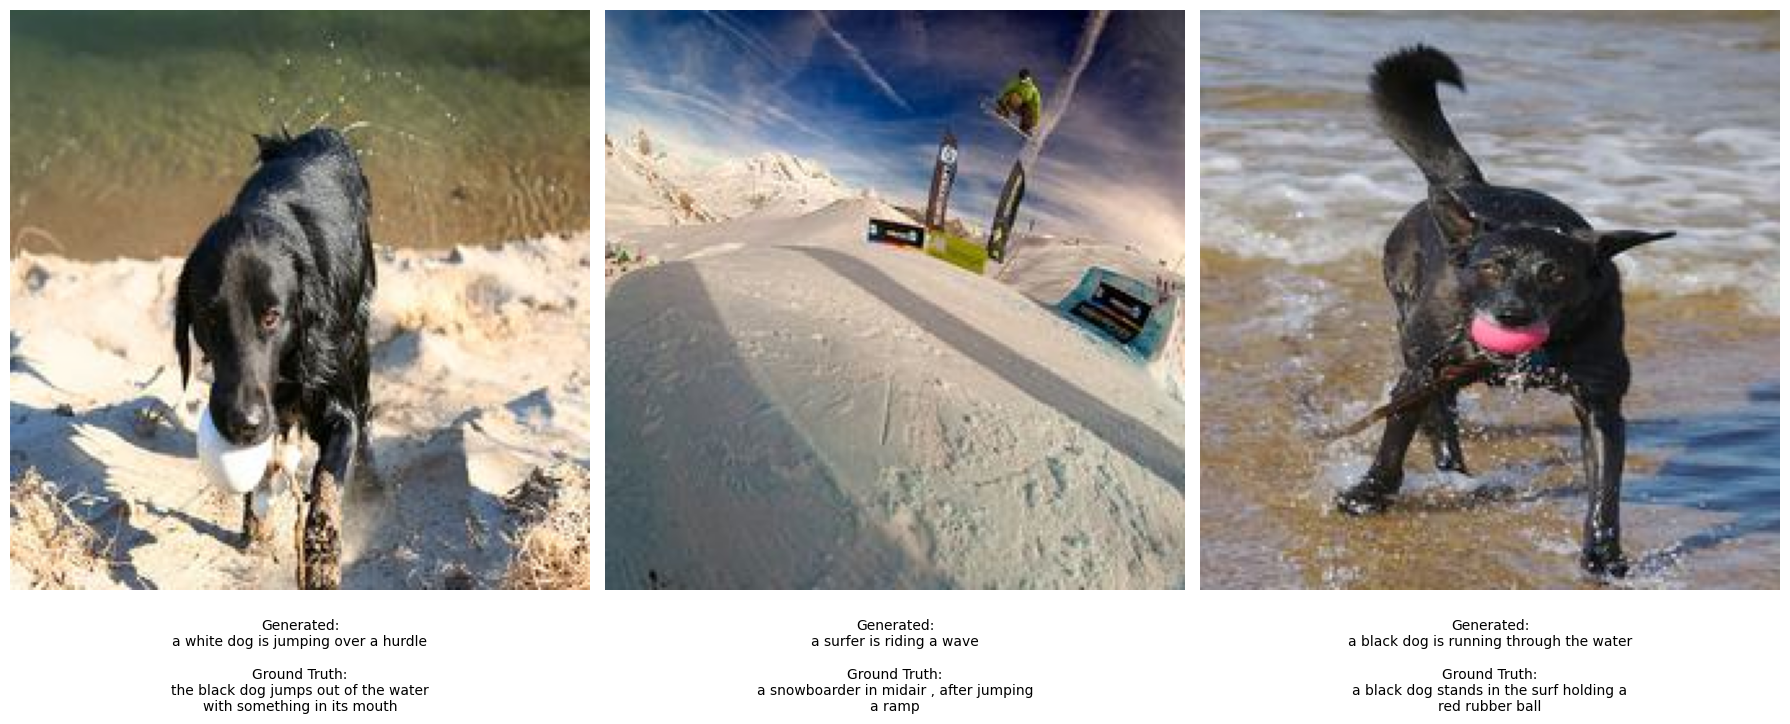

In [43]:
import matplotlib.pyplot as plt
import random
import textwrap

def visualize_results(model, dataset, sp_processor, device, num_samples=3):

    model.eval()
    # pick random test images
    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(18, 8))  # wider figure

    for i, idx in enumerate(indices):
        image, caption_tensor = dataset[idx]

        # generate our model's caption
        gen_caption = generate_caption(model, image, sp_processor, device=device)

        # get the ground truth (just one of them for display)
        gt_ids = caption_tensor.tolist()
        gt_caption = sp_processor.decode(gt_ids)
        # plotting
        ax = plt.subplot(1, num_samples, i + 1)

        # before plotting the image, we denormalize it so matplotlib can show it cleanly
        image = transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],std=[1/0.229, 1/0.224, 1/0.225])(image)
        # permute because pytorch is (C, H, W) but matplotlib wants (H, W, C)
        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.axis('off')

        # wrap text to avoid overlap
        text = (
            f"Generated:\n{textwrap.fill(gen_caption, 40)}\n\n"
            f"Ground Truth:\n{textwrap.fill(gt_caption, 40)}"
        )

        # put text below image
        ax.text(
            0.5, -0.05, text,
            ha='center', va='top',
            transform=ax.transAxes,
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

# run the visualization on the test set
visualize_results(model, test_set, sp, device, num_samples=3)

From these few examples, it is clear that the model does not fully understand the images, but that it does seem to get some concepts from the images. Since the dataset is small, performance was expected to be limited.

## Evaluation (BLEU & BERT-score)

The visual inspection we did above, is nice for the purpose of seeing that the model is working, in the sense that it does generate captions and that it does seem to get certain concepts from the images. However, such visual inspection is subjective and more scientifically rigorous testing is needed to assess the performance of the model. Hence, we're calculating some standard metrics on the test set to assess the performance of our model.

* **BLEU-4**: the standard metric for captioning. It checks n-gram overlap.
* **BERT-Score**: checks semantic similarity using embeddings (better for synonyms).

We used the `torchmetrics` library for this. The loop is a bit slow because we have to run inference on every single image in the test set.

In [49]:
# install torchmetrics and bert_score
!pip install torchmetrics bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.1 MB/s eta 0:00:00


In [45]:
from torchmetrics.text import BLEUScore, BERTScore
from tqdm import tqdm # Just to see a progress bar

def calculate_metrics(model, split_file, image_dir, sp_processor, device):

    model.eval()

    # Initializing the metrics
    bleu1 = BLEUScore(n_gram=1)
    bleu2 = BLEUScore(n_gram=2)
    bleu3 = BLEUScore(n_gram=3)
    bleu4 = BLEUScore(n_gram=4)


    # BERT SCORE: we use a small model (distilbert) to run it faster on Colab
    bert_score = BERTScore(model_name_or_path="distilbert-base-uncased", device=device)

    preds = []
    targets = []

    # We only look at the entries labed 'test' from the json split file.
    test_entries = [entry for entry in split_file if entry['split'] == 'test']


    print(f"Evaluating on {len(test_entries)} images...")

    for entry in tqdm(test_entries):
        filename = entry['filename']
        #  List of 5 ground truth sentences
        references = entry['sentences']

        # Load and transform image
        img_path = os.path.join(image_dir, filename)
        image = Image.open(img_path).convert("RGB")
        image_tensor = transform_test(image) # We use our existing transform

        # Generating the caption
        pred_caption = generate_caption(model, image_tensor, sp_processor, device=device)

        preds.append(pred_caption)
        targets.append(references)

    print("computing metrics...")

    # BLEU expects preds as list of strings, and targets as list of list of strings
    score_b1 = bleu1(preds, targets)
    score_b2 = bleu2(preds, targets)
    score_b3 = bleu3(preds, targets)
    score_b4 = bleu4(preds, targets)

    # BERTScore also accepts the same fashion of feeding the predicted sentences and reference sentences
    bert_stats = bert_score(preds, targets)
    score_bert = bert_stats['f1'].mean() # Average F1 score across the batch

    results = {
        "BLEU-1": score_b1.item(),
        "BLEU-2": score_b2.item(),
        "BLEU-3": score_b3.item(),
        "BLEU-4": score_b4.item(),
        "BERT-Score (F1)": score_bert.item()
    }

    return results

# Evaluation on the test set
metrics = calculate_metrics(model, split_file, '/content/images', sp, device)

print("\nFINAL SCORES:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

100%|██████████| 1000/1000 [01:12<00:00, 13.78it/s]


computing metrics...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

The following layers were not sharded: transformer.layer.*.attention.out_lin.bias, transformer.layer.*.attention.v_lin.bias, transformer.layer.*.attention.out_lin.weight, transformer.layer.*.sa_layer_norm.weight, transformer.layer.*.output_layer_norm.weight, embeddings.LayerNorm.weight, embeddings.position_embeddings.weight, transformer.layer.*.output_layer_norm.bias, transformer.layer.*.attention.k_lin.weight, transformer.layer.*.attention.v_lin.weight, transformer.layer.*.attention.q_lin.bias, transformer.layer.*.attention.q_lin.weight, transformer.layer.*.ffn.lin*.weight, embeddings.word_embeddings.weight, embeddings.LayerNorm.bias, transformer.layer.*.ffn.lin*.bias, transformer.layer.*.attention.k_lin.bias, transformer.layer.*.sa_layer_norm.bias



FINAL SCORES:
BLEU-1: 0.4892
BLEU-2: 0.2969
BLEU-3: 0.1783
BLEU-4: 0.1101
BERT-Score (F1): 0.7253


We discuss these results in the report. We will also compare these results to the results we obtain on a number of baseline approaches. These baseline approaches are explained in the next section.

## Baselines & Comparisons

To further assess the performance of our model, we will compare it against some baselines.
Since our model overfitted (as expected for a transformer trained from scratch on a small dataset), it will be interesting to see if we can do better using pre-trained approaches.

The 4 baselines we will compare it against:
1.  **Single caption**: train on only 1 caption per image (this tests data hunger).
2.  **Patch size 32x32**: bigger patches = less resolution.
3.  **EfficientNet-v2**: replace our encoder with a pre-trained CNN (frozen).
4.  **CLIP (ViT-B-32)**: use OpenAi's CLIP encoder (frozen).

In [52]:
# --- BASELINE 1: Single Caption --

# 1. Creating the data arrays (with only the 1st caption)
training_images_b1, training_target_b1, training_data_b1 = [], [], []
train_idx = 0

for json_object in split_file:
    if json_object['split'] == 'train':
        filename = json_object['filename']
        image = Image.open(os.path.join(src_dir, filename)).convert("RGB")

        # KEY CHANGE: Only take index 0
        training_images_b1.append(image)
        training_target_b1.append(json_object['sentences'][0])
        training_data_b1.append(train_idx)
        train_idx += 1

# Tokenize
target_b1_clean = [c.rstrip().rstrip('.').rstrip() for c in training_target_b1]
train_tokens_b1 = pad_sequences([sp.encode(c.lower(), add_bos=True, add_eos=True) for c in target_b1_clean])

# Dataloader
train_set_b1 = CustomDataset(training_data_b1, train_tokens_b1, training_images_b1, transform_train)
train_loader_b1 = DataLoader(train_set_b1, batch_size=128, shuffle=True)

# New Model
model_b1 = ImageCaptioningTransformer(256, 2, 2, 4, 512, 2000, patch_size=16).to(device) # We train the exact same architecture, but for a single caption per image.
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=1e-4)


In [53]:
# --- BASELINE 2: Patch Size 32 ---

# Initialize Model with patch_size = 32
model_b2 = ImageCaptioningTransformer(
    embedding_size = 256,
    nr_enc_layers = 2,
    nr_dec_layers = 2,
    nr_heads = 4,
    ffn_hidden_size = 512,
    vocab_size=2000,
    patch_size=32  # changed patch_size
).to(device)

# We will train the exact same architecture, only using patches of 32x32.

optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=1e-4)

# Train using ORIGINAL train_dataloader

In [54]:
# --- BASELINE 3: EfficientNet ---
import torchvision.models as models

class EfficientNetEncoder(nn.Module):
    def __init__(self, embedding_size):
        super().__init__()

        # Load Weights
        weights = models.EfficientNet_V2_S_Weights.DEFAULT

        # Store the transforms
        self.transforms = weights.transforms()

        # Load Model
        self.cnn = models.efficientnet_v2_s(weights=weights)

        # Freeze weights
        for p in self.cnn.parameters():
            p.requires_grad = False

        # Remove classifier and define projection
        self.cnn.classifier = nn.Identity()
        self.proj = nn.Linear(1280, embedding_size)

    def forward(self, x):
        features = self.cnn.features(x) # (B, 1280, 7, 7)
        features = features.permute(0, 2, 3, 1).flatten(1, 2) # (B, 49, 1280)
        return self.proj(features)

# Define Model Wrapper
class EfficientNetCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = EfficientNetEncoder(256)
        self.decoder = Decoder(256, 2, 4, 512, 2000)

    def forward(self, img, captions):
        return self.decoder(captions, self.encoder(img))

print("Initializing EfficientNet Baseline...")
model_b3 = EfficientNetCaptioner().to(device)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=1e-4)


print("Creating Dataset with EfficientNet Transforms...")
train_set_b3 = CustomDataset(training_data, train_tokens, training_images, model_b3.encoder.transforms)
train_loader_b3 = DataLoader(train_set_b3, batch_size=128, shuffle=True)

Initializing EfficientNet Baseline...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:02<00:00, 29.3MB/s]


Creating Dataset with EfficientNet Transforms...


In [55]:
# -BASELINE 4: CLIP ---
!pip install git+https://github.com/openai/CLIP.git
import clip

class CLIPEncoder(nn.Module):
    def __init__(self, embedding_size, dev):
        super().__init__()
        # Loading ViT-B/32
        model, self.preprocess = clip.load("ViT-B/32", device=dev)
        self.visual = model.visual.float()

        # Delete text encoder
        del model.transformer

        # Freeze
        for p in self.visual.parameters():
          p.requires_grad = False
        self.proj = nn.Linear(768, embedding_size)

    def forward(self, x):
        # Manual forward to keep spatial tokens
        x = self.visual.conv1(x)
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
        x = torch.cat([self.visual.class_embedding.to(x.dtype) + torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device), x], dim=1)
        x = x + self.visual.positional_embedding.to(x.dtype)
        x = self.visual.ln_pre(x)
        x = x.permute(1, 0, 2)
        x = self.visual.transformer(x)
        x = x.permute(1, 0, 2)
        return self.proj(x)

class CLIPCaptioner(nn.Module):
    def __init__(self, dev):
        super().__init__()
        self.encoder = CLIPEncoder(256, dev)
        self.decoder = Decoder(256, 2, 4, 512, 2000)
    def forward(self, img, captions):
        return self.decoder(captions, self.encoder(img))

model_b4 = CLIPCaptioner(device).to(device)
optimizer_b4 = torch.optim.Adam(model_b4.parameters(), lr=1e-4)

#We re-create Dataset with the CLIP transforms
train_set_b4 = CustomDataset(training_data, train_tokens, training_images, model_b4.encoder.preprocess)
train_loader_b4 = DataLoader(train_set_b4, batch_size=128, shuffle=True)

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-x5y_szey
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-x5y_szey
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=0eda3e5381aa70caa2203621bb39c7d4eb5f9591167403de5614cde1e73ff353
  Stored in directory: /tmp/pip-ephem-wheel-cache-vpedmw5e/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 70.6MiB/s]


Now that we have prepared the four baselines, we can actually train them. We will do this in the cell below. The training loop will be equivalent to the training loop which we used to train our original model. For each baseline, the model which performs best on the validation set is saved.

In [57]:
import time

# List of baselines to run
baselines = [
    ("Baseline 1 (Single Caption)", model_b1, optimizer_b1, train_loader_b1, 40),
    ("Baseline 2 (Patch 32)",      model_b2, optimizer_b2, train_dataloader, 40), # Uses original loader
    ("Baseline 3 (EfficientNet)",  model_b3, optimizer_b3, train_loader_b3, 40),
    ("Baseline 4 (CLIP)",          model_b4, optimizer_b4, train_loader_b4, 40)
]

criterion = nn.CrossEntropyLoss(ignore_index=0)

for name, model, optimizer, loader, epochs in baselines:
    print(f"\n{'='*60}")
    print(f"STARTING TRAINING: {name}")
    print(f"{'='*60}")

    # Track best validation loss for saving best model
    best_val_loss = float('inf')
    # Early stopping: stop if gap between train and val loss is too large
    MAX_GAP = 0.5
    gap_exceeded_epochs = 0
    patience = 2 # We will stop training if the gap is too large for two consecutive epochs

    model.train()

    for epoch in range(epochs):
        start_time = time.time()
        total_loss = 0

        for batch_idx, (images, captions) in enumerate(loader):
            images = images.to(device)
            captions = captions.to(device)

            # Prepare inputs/targets
            decoder_input = captions[:, :-1]
            targets = captions[:, 1:]

            optimizer.zero_grad()

            # Forward pass
            outputs = model(images, decoder_input)

            # Loss calculation
            loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

            # Backward pass
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Logging (less frequent to keep output clean)
            if batch_idx % 100 == 0:
                print(f"  [{name}] Epoch {epoch+1} Batch {batch_idx} Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(loader)
        elapsed = time.time() - start_time

        # Validation after each epoch
        val_loss = calculate_validation_loss(model, validation_dataloader, criterion, device)

        # Calculate gap between train and validation loss
        gap = val_loss - avg_loss

        print(f"Epoch [{epoch+1}/{EPOCHS}] Completed. Train Loss: {avg_loss:.4f} Val Loss: {val_loss:.4f} Gap: {gap:.4f} Time: {elapsed:.0f}s")

        # Early stopping: check if gap is too large
        if gap > MAX_GAP:
            gap_exceeded_epochs += 1
            print(f"  ⚠️  Warning: Gap ({gap:.4f}) exceeds threshold ({MAX_GAP}) - Epoch {gap_exceeded_epochs}")
            if gap_exceeded_epochs >= patience:  # Stop if gap is too large for two consecutive epochs
                print(f"\n{'='*60}")
                print(f"Early stopping triggered!")
                print(f"  Train Loss: {avg_loss:.4f}")
                print(f"  Val Loss: {val_loss:.4f}")
                print(f"  Gap: {gap:.4f} (threshold: {MAX_GAP})")
                print(f"  Best validation loss achieved: {best_val_loss:.4f}")
                print(f"{'='*60}\n")
                break
        else:
            gap_exceeded_epochs = 0  # Reset counter if gap is acceptable

        # Saves best model explicitly
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            filename = f"best_model_{name.replace(' ', '_').lower()}.pth"
            torch.save(model.state_dict(), filename)
            print(f"  ✓ Saved best model with validation loss: {val_loss:.4f}")


print("\nALL BASELINES FINISHED!")


STARTING TRAINING: Baseline 1 (Single Caption)
  [Baseline 1 (Single Caption)] Epoch 1 Batch 0 Loss: 5.5253
Epoch [1/40] Completed. Train Loss: 5.1346 Val Loss: 5.1116 Gap: -0.0230 Time: 13s
  ✓ Saved best model with validation loss: 5.1116
  [Baseline 1 (Single Caption)] Epoch 2 Batch 0 Loss: 4.9216
Epoch [2/40] Completed. Train Loss: 4.7001 Val Loss: 4.8175 Gap: 0.1174 Time: 13s
  ✓ Saved best model with validation loss: 4.8175
  [Baseline 1 (Single Caption)] Epoch 3 Batch 0 Loss: 4.6129
Epoch [3/40] Completed. Train Loss: 4.4320 Val Loss: 4.6181 Gap: 0.1861 Time: 13s
  ✓ Saved best model with validation loss: 4.6181
  [Baseline 1 (Single Caption)] Epoch 4 Batch 0 Loss: 4.2557
Epoch [4/40] Completed. Train Loss: 4.2344 Val Loss: 4.4622 Gap: 0.2277 Time: 13s
  ✓ Saved best model with validation loss: 4.4622
  [Baseline 1 (Single Caption)] Epoch 5 Batch 0 Loss: 4.1461
Epoch [5/40] Completed. Train Loss: 4.0838 Val Loss: 4.3507 Gap: 0.2668 Time: 13s
  ✓ Saved best model with validation

We see that all four baselines also start overfitting after a certain number of epochs, and early stopping is triggered.

## Final evaluation (BLEU-4 & BERT-score)

Now that we have trained the four baselines, we can compare the results of our original model to the results of the four baselines.

In order to compare the performance of our model and the four baselines, we will compute the BLEU-4 and BERT score on the test set for each:

* **BLEU-4**: standard n-gram match.
* **BERT-Score**: semantic similarity (uses bert embeddings).

Make sure you have uploaded the previously saved model states (.pth files) to the Colab storage, as we will load the original model and the four baselines from them and then compute the metrics on the test set.


In [ ]:
# install torchmetrics and bert_score
!pip install torchmetrics bert-score
# Try importing CLIP, install if missing
try:
    import clip
except ImportError:
    !pip install git+https://github.com/openai/CLIP.git
    import clip

In [58]:
import torch
import pandas as pd
from torchmetrics.text import BLEUScore, BERTScore
from tqdm import tqdm
import os
from PIL import Image
import torchvision.models as models

# SETUP: model wrappers
# Re-defining these classes here so we can load the weights without errors.
# We need the structure to exist before we can pour the weights into it.
class EfficientNetEncoder(torch.nn.Module):
    def __init__(self, embedding_size):
        super().__init__()
        weights = models.EfficientNet_V2_S_Weights.DEFAULT
        self.transforms = weights.transforms()
        self.cnn = models.efficientnet_v2_s(weights=weights)
        self.cnn.classifier = torch.nn.Identity()
        self.proj = torch.nn.Linear(1280, embedding_size)
    def forward(self, x):
        features = self.cnn.features(x)
        features = features.permute(0, 2, 3, 1).flatten(1, 2)
        return self.proj(features)

class EfficientNetCaptioner(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = EfficientNetEncoder(256)
        self.decoder = Decoder(256, 2, 4, 512, 2000) # Using our Decoder class
    def forward(self, img, captions):
        return self.decoder(captions, self.encoder(img))

# Wrapper for Baseline 4 (CLIP)
class CLIPVisionEncoder(torch.nn.Module):
    def __init__(self, embedding_size, device):
        super().__init__()
        model, self.preprocess = clip.load("ViT-B/32", device=device)
        self.visual = model.visual.float()
        del model.transformer # Remove text part
        self.proj = torch.nn.Linear(768, embedding_size)
    def forward(self, x):
      # manual forward pass to keep the spatial tokens for cross-attention
        x = self.visual.conv1(x)
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
        x = torch.cat([self.visual.class_embedding.to(x.dtype) + torch.zeros(x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device), x], dim=1)
        x = x + self.visual.positional_embedding.to(x.dtype)
        x = self.visual.ln_pre(x)
        x = x.permute(1, 0, 2)
        x = self.visual.transformer(x)
        x = x.permute(1, 0, 2)
        return self.proj(x)

class CLIPCaptioner(torch.nn.Module):
    def __init__(self, device):
        super().__init__()
        self.encoder = CLIPVisionEncoder(256, device)
        self.decoder = Decoder(256, 2, 4, 512, 2000) # Using our Decoder class
    def forward(self, img, captions):
        return self.decoder(captions, self.encoder(img))


#  ---EVALUATION FUNCTION------
def evaluate_model(model, name, split_file, image_dir, sp_processor, device, transform):
    model.eval()
    print(f"Evaluating {name}...")

    # using bleu-4 (standard) and bert-score (semantic)
    bleu4 = BLEUScore(n_gram=4)
    bert_score = BERTScore(model_name_or_path="distilbert-base-uncased", device=device)

    preds = []
    targets = []

    # get test set
    test_entries = [entry for entry in split_file if entry['split'] == 'test']

    with torch.no_grad():
        for entry in tqdm(test_entries):
            img_path = os.path.join(image_dir, entry['filename'])
            image = Image.open(img_path).convert("RGB")
            # applying the correct transform (efficientnet/clip need specific ones)
            image_tensor = transform(image).unsqueeze(0).to(device)

            # handling the different ways the models are structured
            if hasattr(model, 'patcher'): # original, B1, B2
                patches = model.patcher(image_tensor)
                patches = model.pos_encoder_img(patches)
                encoder_output = model.encoder(patches)
            elif hasattr(model, 'encoder'): # EfficientNet, CLIP
                encoder_output = model.encoder(image_tensor)

            # greedy decoding loop
            start_token = sp_processor.bos_id()
            generated_ids = [start_token]
            for _ in range(30):
                decoder_input = torch.tensor(generated_ids).unsqueeze(0).to(device)
                output = model.decoder(decoder_input, encoder_output)
                next_token = output[0, -1, :].argmax(dim=-1).item()
                if next_token == sp_processor.eos_id():
                    break
                generated_ids.append(next_token)

            preds.append(sp_processor.decode(generated_ids))
            targets.append(entry['sentences'])

    return {
        "Model": name,
        "BLEU-4": bleu4(preds, targets).item(),
        "BERT-Score": bert_score(preds, targets)['f1'].mean().item()
    }

#### RUN COMPARISON
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

# loading our model
print("\n--- Loading Our Model ---")
model_ours = ImageCaptioningTransformer(256, 2, 2, 4, 512, 2000, patch_size=16).to(device)
#We load the model from Colab storage
model_ours.load_state_dict(torch.load('best_model.pth', map_location=device))
results.append(evaluate_model(model_ours, "Our Model", split_file, '/content/images', sp, device, transform_test))

#  Load Baseline 1 (Single Caption)
print("\n--- Loading Baseline 1 ---")
model_b1 = ImageCaptioningTransformer(256, 2, 2, 4, 512, 2000, patch_size=16).to(device)
model_b1.load_state_dict(torch.load('best_model_baseline_1_(single_caption).pth', map_location=device))
results.append(evaluate_model(model_b1, "Baseline 1 (Single Cap)", split_file, '/content/images', sp, device, transform_test))

# Load Baseline 2 (Patch 32)
print("\n--- Loading Baseline 2 ---")
model_b2 = ImageCaptioningTransformer(256, 2, 2, 4, 512, 2000, patch_size=32).to(device) # <--- patch_size 32
model_b2.load_state_dict(torch.load('best_model_baseline_2_(patch_32).pth', map_location=device))
results.append(evaluate_model(model_b2, "Baseline 2 (Patch 32)", split_file, '/content/images', sp, device, transform_test))

# Load Baseline 3 (EfficientNet)
print("\n--- Loading Baseline 3 ---")
model_b3 = EfficientNetCaptioner().to(device)
model_b3.load_state_dict(torch.load('best_model_baseline_3_(efficientnet).pth', map_location=device))
eff_trans = models.EfficientNet_V2_S_Weights.DEFAULT.transforms()
results.append(evaluate_model(model_b3, "Baseline 3 (EfficientNet)", split_file, '/content/images', sp, device, eff_trans))

# Load Baseline 4 (CLIP)
print("\n--- Loading Baseline 4 ---")
model_b4 = CLIPCaptioner(device).to(device)
model_b4.load_state_dict(torch.load('best_model_baseline_4_(clip).pth', map_location=device))
_, clip_preprocess = clip.load("ViT-B/32", device=device)
results.append(evaluate_model(model_b4, "Baseline 4 (CLIP)", split_file, '/content/images', sp, device, clip_preprocess))

# ==========================================
# 4. SHOW RESULTS
# ==========================================
df = pd.DataFrame(results)
print("\n" + "="*50)
print("FINAL PROJECT REPORT TABLE")
print("="*50)
print(df.to_markdown(index=False))


--- Loading Our Model ---
Evaluating Our Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...


--- Loading Baseline 3 ---
Evaluating Baseline 3 (EfficientNet)...


100%|██████████| 1000/1000 [01:34<00:00, 10.60it/s]
The following layers were not sharded: transformer.layer.*.output_layer_norm.bias, transformer.layer.*.attention.v_lin.weight, transformer.layer.*.attention.q_lin.weight, transformer.layer.*.attention.q_lin.bias, transformer.layer.*.sa_layer_norm.weight, embeddings.LayerNorm.weight, embeddings.LayerNorm.bias, transformer.layer.*.sa_layer_norm.bias, transformer.layer.*.attention.k_lin.weight, transformer.layer.*.output_layer_norm.weight, transformer.layer.*.attention.out_lin.bias, transformer.layer.*.ffn.lin*.weight, transformer.layer.*.attention.v_lin.bias, transformer.layer.*.attention.k_lin.bias, transformer.layer.*.ffn.lin*.bias, embeddings.word_embeddings.weight, embeddings.position_embeddings.weight, transformer.layer.*.attention.out_lin.weight



--- Loading Baseline 4 ---
Evaluating Baseline 4 (CLIP)...


100%|██████████| 1000/1000 [01:14<00:00, 13.34it/s]
The following layers were not sharded: transformer.layer.*.output_layer_norm.bias, transformer.layer.*.attention.v_lin.weight, transformer.layer.*.attention.q_lin.weight, transformer.layer.*.attention.q_lin.bias, transformer.layer.*.sa_layer_norm.weight, embeddings.LayerNorm.weight, embeddings.LayerNorm.bias, transformer.layer.*.sa_layer_norm.bias, transformer.layer.*.attention.k_lin.weight, transformer.layer.*.output_layer_norm.weight, transformer.layer.*.attention.out_lin.bias, transformer.layer.*.ffn.lin*.weight, transformer.layer.*.attention.v_lin.bias, transformer.layer.*.attention.k_lin.bias, transformer.layer.*.ffn.lin*.bias, embeddings.word_embeddings.weight, embeddings.position_embeddings.weight, transformer.layer.*.attention.out_lin.weight



FINAL PROJECT REPORT TABLE
| Model                     |    BLEU-4 |   BERT-Score |
|:--------------------------|----------:|-------------:|
| Our Model                 | 0.110665  |     0.723014 |
| Baseline 1 (Single Cap)   | 0.0765828 |     0.728564 |
| Baseline 2 (Patch 32)     | 0.0939318 |     0.726134 |
| Baseline 3 (EfficientNet) | 0.157236  |     0.718724 |
| Baseline 4 (CLIP)         | 0.219053  |     0.71309  |


The results and comparisons are discussed in the report.